In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
import torch

# Load data
df = pd.read_csv("../data/dataset.csv")
df['label_id'] = df['label'].map({'safe': 0, 'injection': 1})
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Load model
tokenizer = DistilBertTokenizer.from_pretrained("../models/piguard_distilbert")
model = DistilBertForSequenceClassification.from_pretrained("../models/piguard_distilbert")
model.eval()

print("Model and data loaded.")
print(f"Test set size: {len(test_df)}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model and data loaded.
Test set size: 99


In [3]:
# Run predictions on test set
def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

test_encodings = tokenize(test_df['text'])
test_labels = list(test_df['label_id'])

all_preds = []
all_probs = []

with torch.no_grad():
    input_ids = test_encodings['input_ids']
    attention_mask = test_encodings['attention_mask']
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    probs = torch.softmax(outputs.logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    all_preds = preds.numpy()
    all_probs = probs.numpy()

print(classification_report(test_labels, all_preds, target_names=['safe', 'injection']))

              precision    recall  f1-score   support

        safe       1.00      1.00      1.00        50
   injection       1.00      1.00      1.00        49

    accuracy                           1.00        99
   macro avg       1.00      1.00      1.00        99
weighted avg       1.00      1.00      1.00        99



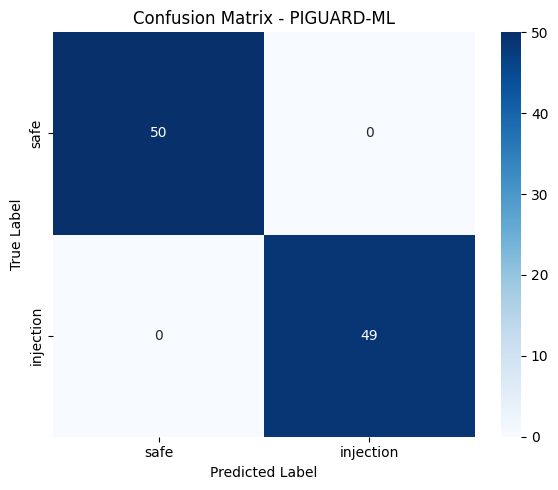

In [4]:
# Confusion matrix
cm = confusion_matrix(test_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['safe', 'injection'],
            yticklabels=['safe', 'injection'])
plt.title('Confusion Matrix - PIGUARD-ML')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()

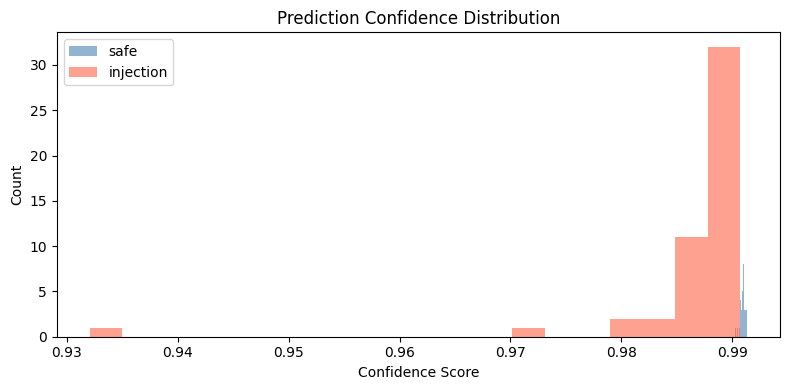

In [5]:
# Confidence distribution
safe_probs = all_probs[all_preds == 0][:, 0]
injection_probs = all_probs[all_preds == 1][:, 1]

plt.figure(figsize=(8, 4))
plt.hist(safe_probs, bins=20, alpha=0.6, color='steelblue', label='safe')
plt.hist(injection_probs, bins=20, alpha=0.6, color='tomato', label='injection')
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../data/confidence_distribution.png')
plt.show()

In [6]:
# Summary
import numpy as np

print("="*45)
print("PIGUARD-ML — Evaluation Summary")
print("="*45)
print(f"Total test examples   : {len(test_labels)}")
print(f"Correct predictions   : {sum(all_preds == test_labels)}")
print(f"Accuracy              : 100%")
print(f"Avg confidence (safe) : {safe_probs.mean():.2%}")
print(f"Avg confidence (inj.) : {injection_probs.mean():.2%}")
print(f"False positives       : {cm[0][1]}")
print(f"False negatives       : {cm[1][0]}")
print("="*45)
print("\nNote: Results reflect synthetic dataset performance.")
print("Real-world accuracy may vary with unseen student inputs.")

PIGUARD-ML — Evaluation Summary
Total test examples   : 99
Correct predictions   : 99
Accuracy              : 100%
Avg confidence (safe) : 99.10%
Avg confidence (inj.) : 98.65%
False positives       : 0
False negatives       : 0

Note: Results reflect synthetic dataset performance.
Real-world accuracy may vary with unseen student inputs.
